In [17]:
from langgraph.graph import END, START, StateGraph
from typing import TypedDict 
import subprocess
from openai import OpenAI

class State(TypedDict):
    video_file : str
    audio_file : str
    tracscription : str

In [ ]:
# 노드 생성 

# 오디오 추출 (FFmpeg를 사용해서)
from openai.types.audio import transcription


def extract_audio(state : State):
    output_file = state["video_file"].replace("mp4","mp3") # mp4 -> mp3로 변환
    #ffmpeg - 이걸 이렇게 해주는 이유는 openai는 변환 작업에 대해 분당 요금을 받기 때문이다.  또한 오디오 파일의 속도를 빠르게 해서 변환해도 퀄리티가 떨어지지않음 (이로인해 변환비용 감소 )
    command = [
        "ffmpeg",
        "-i", 
        state["video_file"],
        "-filter:a",# 수정작업 
        "atempo=2.0" , #속도 임 2배 설정 
        "-y",  # ffmpeg에게 해당 파일을 덮어씌울 것인지 물어보면 yes라고 대답하도록 하는 코드  
        output_file
    ]
    subprocess.run(command)
    return{
        "audio_file" : output_file
    }

# 오디오 파일 변환 
def transcribe_audio(state : State):
    # use audio file 
    client = OpenAI()
    with open(state["audio_file"], "rb") as audio_file:
        transcription = client.audio.transcriptions.create(
            model = "whisper-1",
            response_format= "text",
            file = audio_file,
            language= "en", # 모델에게 영상이 어떤 언어로 되어있는지 알려주는것 , 모델에게 주는 힌트 
            prompt= "Netherlands, Rotterdam, Amsterdam, THe Hage" # gpt 프롬포트 같은게 아닌 모델에 단어 목록 같은 걸 주는 것임. (d이걸 주지 않으면 모델이 저 사람이 뭐라고 말하는지 알아내는게 힘들 수도있음, 모델이 듣게될 단어에 대한 힌트)
        )
        return{
            "transcription" : transcription
        }

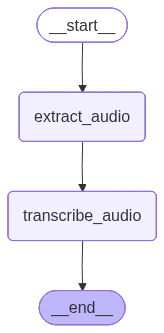

In [19]:
# 그래프 생성 

graph_builder = StateGraph(State)

graph_builder.add_node("extract_audio",extract_audio)
graph_builder.add_node("transcribe_audio",transcribe_audio)

graph_builder.add_edge(START, "extract_audio")
graph_builder.add_edge("extract_audio", "transcribe_audio")
graph_builder.add_edge("transcribe_audio", END)

graph = graph_builder.compile()

graph

In [ ]:
graph.invoke({"video_file": "netherlands.mp4"})